---
title: "Quarto regression notebook"
description: Regression target covering the main Quarto features used by this site.
date: "2026-04-24"
categories:
  - Quarto
  - Regression
  - Layout
image: featured.png
author: Alejandro Fontal
bibliography: references.bib
link-citations: true
format:
  html:
    toc: true
    toc-location: right
    smooth-scroll: true
    number-sections: false
---


# Introduction

This notebook is a regression target for the publishing pipeline. It intentionally mixes Quarto layout primitives, rich markdown, code cells, tables, and figures so we can validate that the Astro-integrated render stays coherent.

::: {.column-margin}
Margin content should sit in the right rail without changing the main body width.
:::

The goal is not visual beauty. The goal is to make breakage obvious.


## Callouts and Details

::: {.callout-note collapse="true"}
## Collapsible note

This note checks Quarto callout rendering, spacing, and collapse behavior.
:::

::: {.callout-warning}
## Warning state

Warnings should inherit the site theme while remaining clearly distinguished from plain prose.
:::

<details>
<summary>Native details element</summary>
<p>This checks the default browser disclosure plus our post layout spacing.</p>
</details>


## Panel Tabset

::: {.panel-tabset}
### Summary

The first tab contains standard prose and inline `code`.

### Checklist

- ToC generation
- Tab styling
- Hover and active states
- Content spacing inside a tab panel
:::


## Columns and Margin Content

::: {.columns}
::: {.column width="55%"}
This left column should align with the main prose width and remain readable on desktop.

It also contains a short list:

- one
- two
- three
:::

::: {.column width="45%"}
This right column should not force unrelated code or comments to widen.

::: {.column-margin}
A nested margin note should still use the rail.
:::
:::
:::


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

RNG = np.random.default_rng(7)
NOTEBOOK_DIR = Path.cwd()
print(f"Notebook directory: {NOTEBOOK_DIR.name}")
print('Quarto regression imports loaded.')
sys.stderr.write('stderr line for regression testing\n')


Notebook directory: quarto-regression
Quarto regression imports loaded.


stderr line for regression testing


35

In [2]:
table_df = pd.DataFrame(
    {
        'feature': [
            'ToC',
            'Callouts',
            'Tabsets',
            'Code copy',
            'Wide figure',
            'Comments shell',
        ],
        'expected': [
            'right rail',
            'spaced and tinted',
            'single active panel',
            'hover button only',
            'expands beyond prose',
            'same main column width',
        ],
        'status': ['manual check'] * 6,
    }
)

table_df


,feature,expected,status
0,ToC,right rail,manual check
1,Callouts,spaced and tinted,manual check
2,Tabsets,single active panel,manual check
3,Code copy,hover button only,manual check
4,Wide figure,expands beyond prose,manual check
5,Comments shell,same main column width,manual check


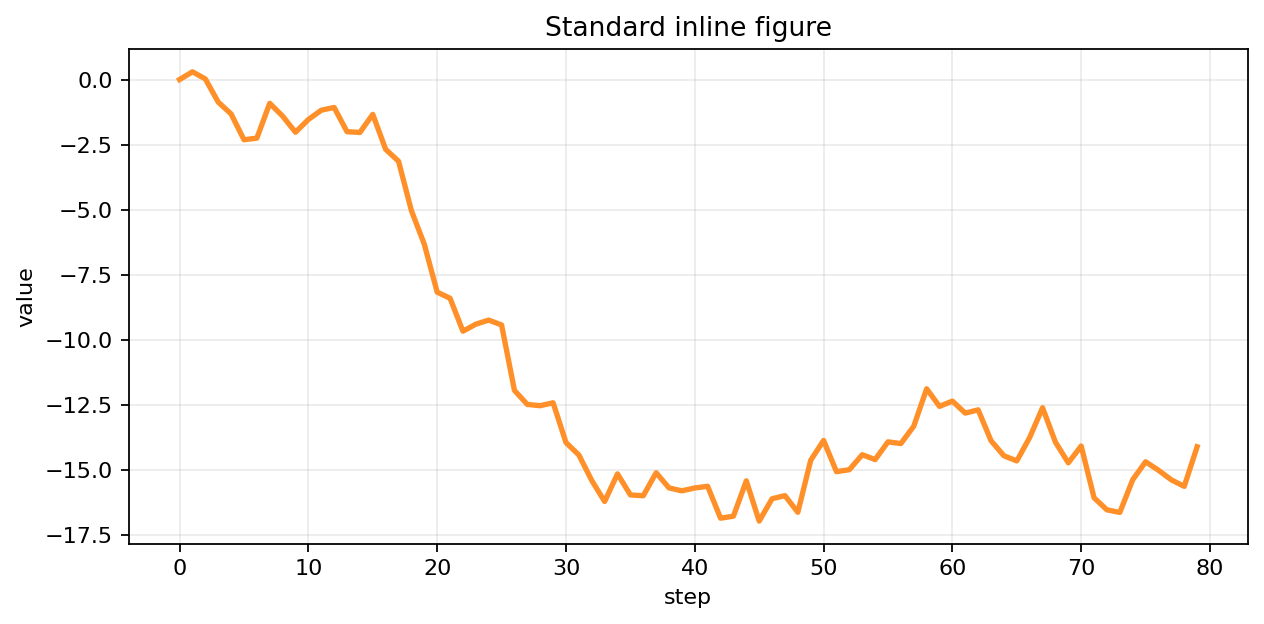

In [3]:
series = np.cumsum(RNG.normal(size=80))
fig, ax = plt.subplots(figsize=(8, 4), dpi=160)
ax.plot(series, color='#ff9029', linewidth=2.4)
ax.set_title('Standard inline figure')
ax.set_xlabel('step')
ax.set_ylabel('value')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Wide Layout Stress Test

The figure below should be allowed to expand beyond the prose column without changing the main text width above it.

::: {.page-columns .page-full}
![](wide_grid.png){.column-page-inset fig-alt="Wide layout regression figure"}
:::


In [4]:
long_named_values = {
    'header_alignment': True,
    'toc_should_not_resize_body': True,
    'comments_should_match_prose_column': True,
    'page_full_outputs_should_stay_within_page_shell': True,
    'copy_buttons_should_not_shift_code_cells': True,
}

display(Markdown('\n'.join(f'- **{key}**: `{value}`' for key, value in long_named_values.items())))


- **header_alignment**: `True`
- **toc_should_not_resize_body**: `True`
- **comments_should_match_prose_column**: `True`
- **page_full_outputs_should_stay_within_page_shell**: `True`
- **copy_buttons_should_not_shift_code_cells**: `True`

## Citations, Footnotes, and Math

Quarto should render standard citations like @wickham2016 and grouped citations such as [@xie2018; @wilke2019]. It should also keep inline footnotes readable.^[Inline footnotes should not distort paragraph spacing or line height.]

A referenced footnote should land in the document notes area without breaking the main layout.[^regression-footnote]

The renderer should also preserve display math:

$$
L(x) = \frac{1}{1 + e^{-x}} + \sum_{i=1}^{3} \frac{i}{10}
$$

[^regression-footnote]: Referenced footnotes should appear near the end of the document and stay aligned with the main text column.


## Summary

If this notebook renders cleanly, we should be confident about the main Quarto capabilities this site currently claims to support.
